# Vehicle Maintenance
**Target:** `Need_Maintenance` (0 / 1)

**Pipeline summary:**
1. Data cleaning (null removal)
2. Date feature engineering (days-ago)
3. Outlier removal (IQR)
4. Feature selection via Mutual Information + Spearman heat-map
5. Train / Test split (80/20)
6. Column-transformer preprocessing — OrdinalEncoder (hierarchical), OneHotEncoder (nominal), RobustScaler (numerical)
7. SMOTE on training set only
8. **Decision Tree** with GridSearchCV — train & test accuracy reported separately

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import date

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, RobustScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from imblearn.over_sampling import SMOTE
import kagglehub
path = kagglehub.dataset_download("chavindudulaj/vehicle-maintenance-data")

100%|██████████| 1.77M/1.77M [00:00<00:00, 91.8MB/s]

Extracting files...


In [ ]:
file_path = os.path.join(path, "vehicle_maintenance_data.csv")
df = pd.read_csv(file_path)
df.head(3)

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,2023-11-23,2025-06-24,Second,20782,6,3,13.622204,New,New,Weak,1
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,2023-09-21,2025-06-04,Second,23489,7,0,13.625307,New,New,Weak,1
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,2023-06-27,2025-04-27,First,17979,7,0,14.306302,New,Good,Weak,1


In [ ]:
df.shape

(50000, 20)

In [ ]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

In [ ]:
REFERENCE_DATE = pd.Timestamp("2026-02-20")

for col in ["Last_Service_Date", "Warranty_Expiry_Date"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")
    df[col + "_days"] = (REFERENCE_DATE - df[col]).dt.days

df.drop(columns=["Last_Service_Date", "Warranty_Expiry_Date"], inplace=True)

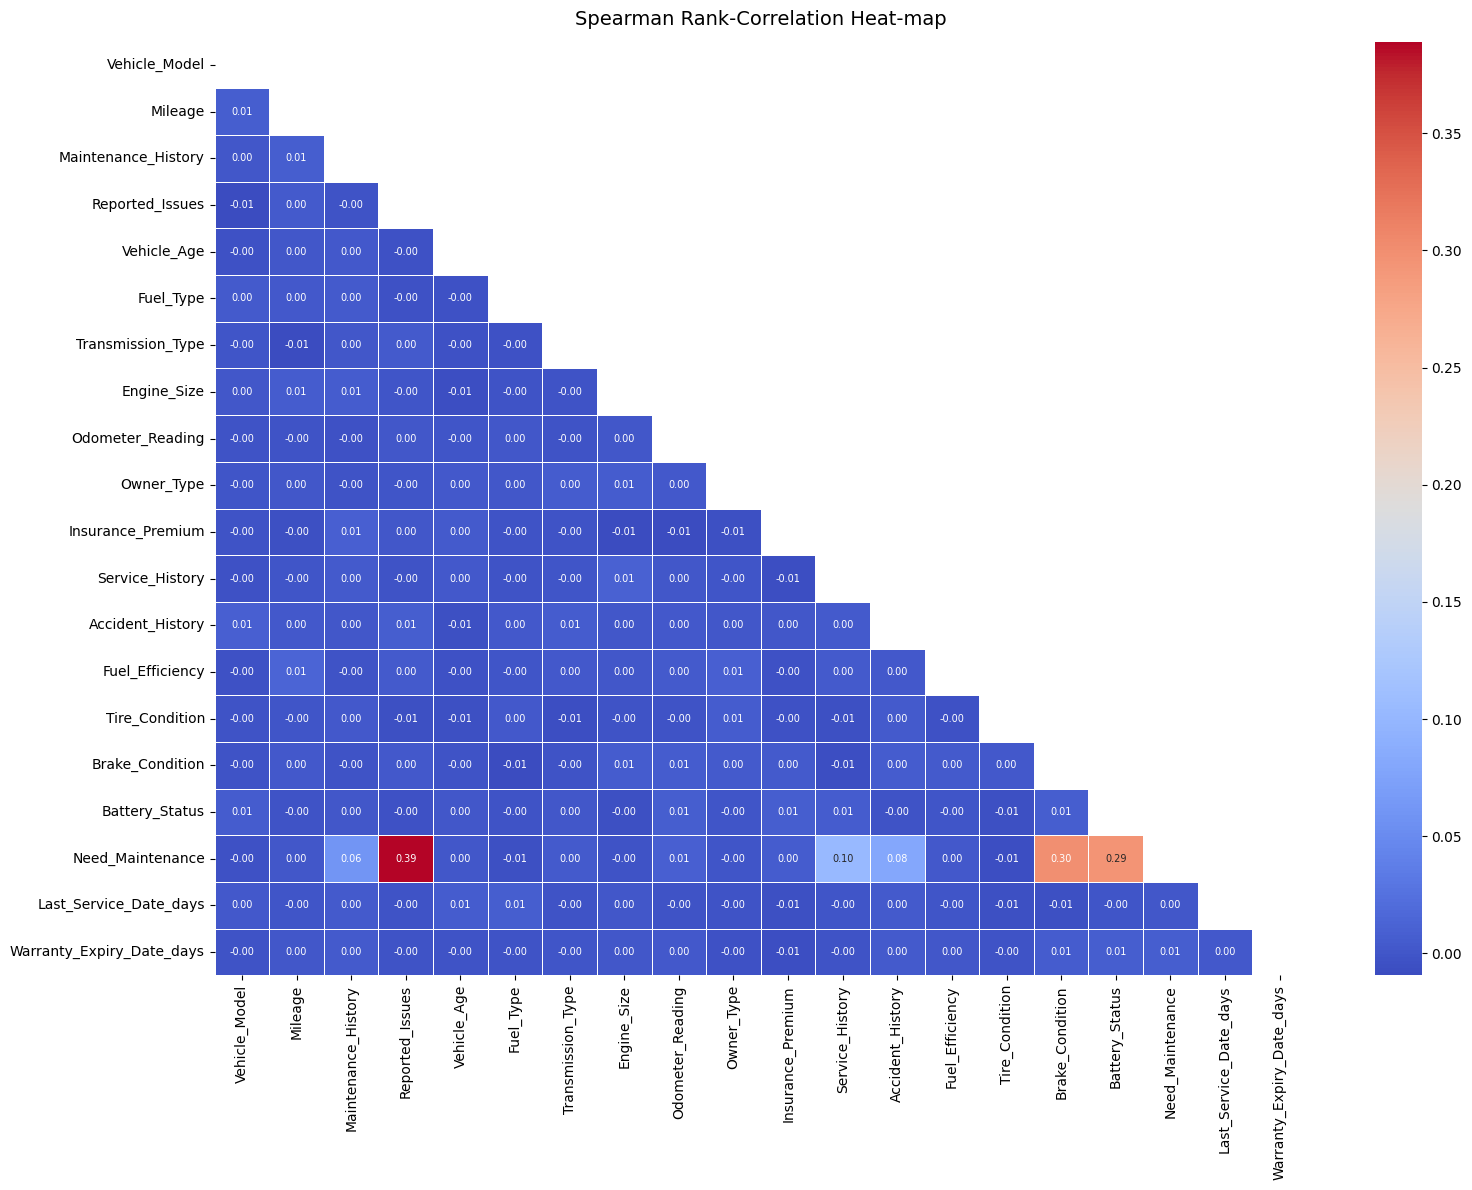

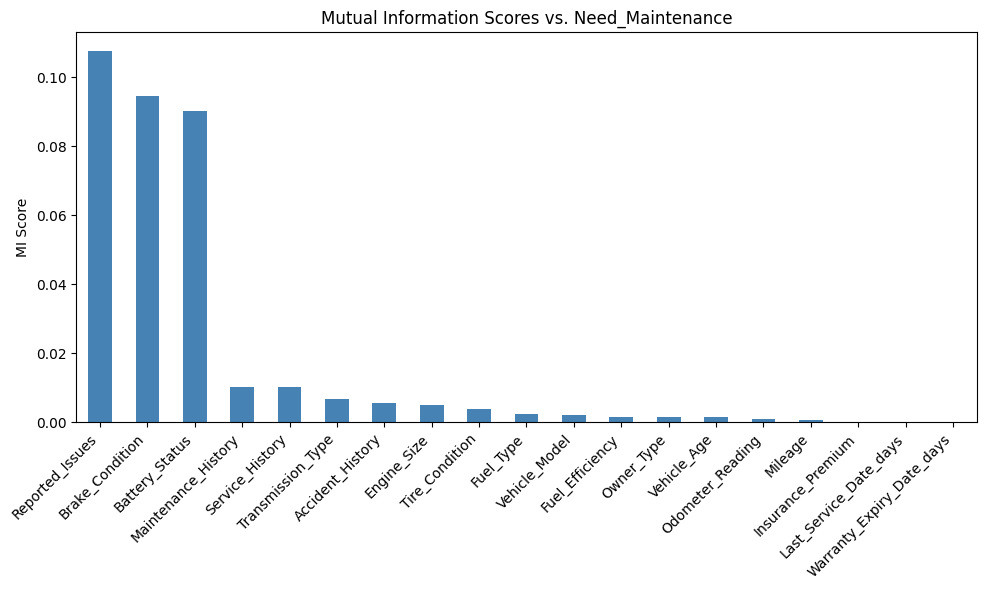

In [ ]:
df_encoded = df.copy()
cat_cols_tmp = df_encoded.select_dtypes(include="object").columns.tolist()
le = LabelEncoder()
for c in cat_cols_tmp:
    df_encoded[c] = le.fit_transform(df_encoded[c].astype(str))

spearman_corr = df_encoded.corr(method="spearman")

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
sns.heatmap(
    spearman_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 7},
)
plt.title("Spearman Rank-Correlation Heat-map", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

X_tmp = df_encoded.drop(columns=["Need_Maintenance"])
y_tmp = df_encoded["Need_Maintenance"]

mi_scores = mutual_info_classif(X_tmp, y_tmp, discrete_features="auto", random_state=42)
mi_series = pd.Series(mi_scores, index=X_tmp.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
mi_series.plot(kind="bar", color="steelblue")
plt.title("Mutual Information Scores vs. Need_Maintenance")
plt.ylabel("MI Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

zero_mi_features = mi_series[mi_series == 0].index.tolist()
if zero_mi_features:
    df.drop(columns=zero_mi_features, inplace=True)

In [ ]:
ordinal_features = {
    "Maintenance_History": ["Poor", "Average", "Good"],
    "Tire_Condition":      ["Worn Out", "Good", "New"],
    "Brake_Condition":     ["Worn Out", "Good", "New"],
    "Battery_Status":      ["Weak", "Good", "Strong"],
}

nominal_features = [
    c for c in ["Vehicle_Model", "Fuel_Type", "Transmission_Type", "Owner_Type"]
    if c in df.columns
]

numerical_features = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c != "Need_Maintenance"
]

ordinal_features = {k: v for k, v in ordinal_features.items() if k in df.columns}

X = df.drop(columns=["Need_Maintenance"])
y = df["Need_Maintenance"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
ordinal_transformer = OrdinalEncoder(
    categories=[ordinal_features[k] for k in ordinal_features],
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)

nominal_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
)

numerical_transformer = RobustScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("ord", ordinal_transformer,  list(ordinal_features.keys())),
        ("nom", nominal_transformer,  nominal_features),
        ("num", numerical_transformer, numerical_features),
    ],
    remainder="drop",
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

In [ ]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_proc, y_train)

In [ ]:
y_train_sm.value_counts()

,count
Need_Maintenance,
1,32398
0,32398


In [ ]:
X_test.shape

(10000, 16)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_param_grid = {
    "max_depth":        [3, 5, 7, 10, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion":        ["gini", "entropy"],
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=0,
)
dt_grid.fit(X_train_sm, y_train_sm)

best_dt = dt_grid.best_estimator_

y_pred_dt_train = best_dt.predict(X_train_sm)
y_pred_dt       = best_dt.predict(X_test_proc)

Train Accuracy : 1.0000
Test  Accuracy : 1.0000
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1900
           1     1.0000    1.0000    1.0000      8100

    accuracy                         1.0000     10000
   macro avg     1.0000    1.0000    1.0000     10000
weighted avg     1.0000    1.0000    1.0000     10000



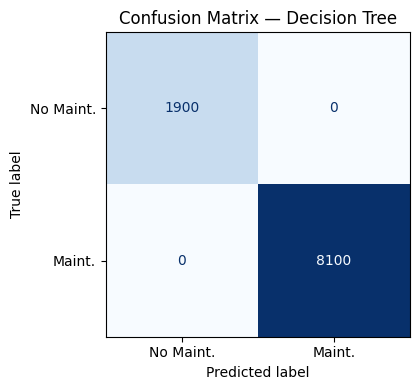

In [ ]:
train_acc = accuracy_score(y_train_sm, y_pred_dt_train)
test_acc  = accuracy_score(y_test,     y_pred_dt)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test  Accuracy : {test_acc:.4f}")

print(classification_report(y_test, y_pred_dt, digits=4))

cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Maint.", "Maint."])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Decision Tree", fontsize=12)
plt.tight_layout()
plt.show()